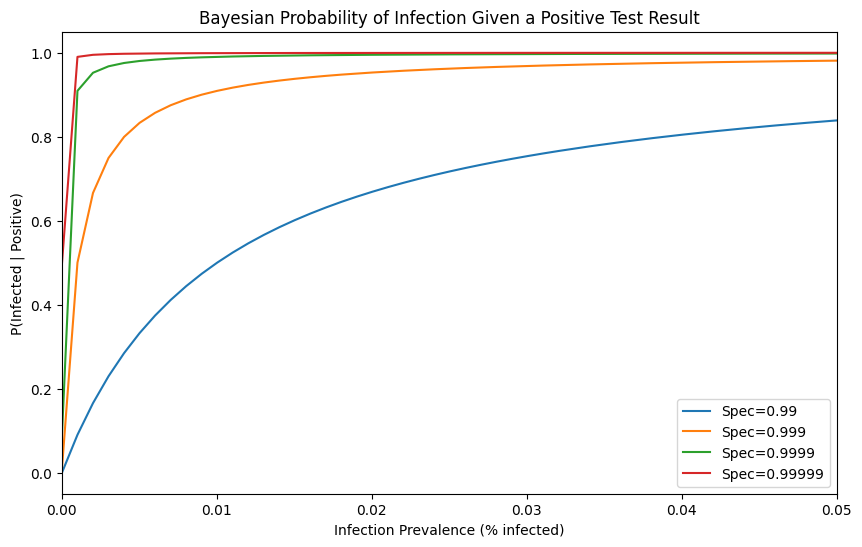

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 

infection_prevalence = np.linspace(0.00001, 0.5, 500)          # between 0.00001 and 0.5
specificity = [0.99, 0.999, 0.9999, 0.99999]                     # between 0 and 1
sensitivity = 0.99

# P(Infected | Positive) = (P(Positive | Infected) * P(Infected)) / P(Positive)     Bayesian probability formula
def bayesian_probability(infection_prevalence, specifity, sensitivity):
    
    P_infected = infection_prevalence               # P(Infected)
    P_not_infected = 1 - infection_prevalence       # P(Healthy)                 
    P_positive_given_infected = sensitivity         # P(Positive | Infected)   TP
    P_positive_given_not_infected = 1 - specifity   # P(Positive | Healthy)    FP

    # number/probability of test being positive = TP*P(Infected) + FP*P(Healthy)
    P_positive = (P_positive_given_infected * P_infected) + (P_positive_given_not_infected * P_not_infected)  # P(Positive) 
    P_infected_given_positive = (P_positive_given_infected * P_infected) / P_positive
    return P_infected_given_positive


# plotting the results
plt.figure(figsize=(10, 6))
for spec in specificity:
    for sens in [sensitivity]:
        P_infected_given_positive = bayesian_probability(infection_prevalence, spec, sens)
        plt.plot(infection_prevalence, P_infected_given_positive, label=f'Spec={spec}')    
        plt.xlim(0,0.05)
        plt.legend()
        plt.xlabel('Infection Prevalence (% infected)')
        plt.ylabel('P(Infected | Positive)')
        plt.title('Bayesian Probability of Infection Given a Positive Test Result')
        
        

The results show that even high specificites above 0.99 struggle to yield reliable results to answer how high is the probability of being infected given the positive test.

# Explaining Results with Integers
- Population of 100'000
- for the case:
  - 0.05 infected (P) = 5'000
  - 0.95 not infected (N) = 95'000
  - 0.99 sensitivity 
  - 0.99 specificity
- TP = 0.99 * 5000 = 4950
- FP = (1 - 0.99) * 95000 = 950
- Total positive tests = TTP = TP + FP = 4950 + 950 = 5900
- P(infected | positive) = TP / TTP = 4950 / 5900 = **0.838**

In [27]:
# Check
bayesian_probability(0.05, 0.99, 0.99)

0.8389830508474575